<a href="https://colab.research.google.com/github/franruedaesq/loanflow-nlp-pipeline/blob/notebook-text-classifier/1%C2%A0%C2%B7%C2%A0Text%E2%80%AFClassifier%09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install -q transformers datasets accelerate evaluate onnx onnxruntime optimum s3fs rich

In [ ]:
import os, json, random, torch, itertools, pathlib
from pathlib import Path

In [ ]:
from datasets import Dataset

# DATA_PATH = Path("data/raw/train.jsonl")
DATA_PATH = Path("merged_dataset.jsonl")
records = [json.loads(line) for line in DATA_PATH.open()]
ds = Dataset.from_list(records)
ds = ds.shuffle(seed=42)
ds = ds.train_test_split(test_size=0.2, seed=42)
ds


DatasetDict({
    train: Dataset({
        features: ['reason', 'free_text', 'step', 'id'],
        num_rows: 1184
    })
    test: Dataset({
        features: ['reason', 'free_text', 'step', 'id'],
        num_rows: 296
    })
})

In [ ]:
from collections import Counter
Counter(ds['train']['reason'])


Counter({'ui_error': 65,
         'process_too_complex': 168,
         'income_not_verifiable': 78,
         'technical_issue': 83,
         'unexpected_behavior': 211,
         'other': 127,
         'waiting_period_too_long': 168,
         'wrong_values': 95,
         'fees_unexpected': 134,
         'changed_mind': 55})

In [ ]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

labels = sorted(set(ds['train']['reason']))
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

In [ ]:
label2id

{'changed_mind': 0,
 'fees_unexpected': 1,
 'income_not_verifiable': 2,
 'other': 3,
 'process_too_complex': 4,
 'technical_issue': 5,
 'ui_error': 6,
 'unexpected_behavior': 7,
 'waiting_period_too_long': 8,
 'wrong_values': 9}

In [ ]:
#  show first 4 rows
ds['train'][:4]

{'reason': ['ui_error',
  'process_too_complex',
  'income_not_verifiable',
  'technical_issue'],
 'free_text': ['I was trying to enter my income details, but the form kept resetting my inputs every time I moved to the next field. It was really frustrating and made me stop the application.',
  'I started the mortgage application but found the process quite overwhelming and complicated. There were too many steps and too much information required all at once. I decided to pause and might try again later when I feel more prepared.',
  "I couldn't find the right documents to upload to verify my income, so I had to stop here.",
  'I kept trying to enter my information but the website kept freezing on me.'],
 'step': ['Borrower Selection',
  'Borrower Selection',
  'Verify Liabilities',
  'Collect Declarations'],
 'id': ['ex-00096',
  'ex-00256',
  '02300f55-3c67-402c-812c-1fff3e986eea',
  '8db6da8b-883b-408c-a3e6-f452354bd972']}

In [ ]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

labels = sorted(set(ds['train']['reason']))
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

def tokenize(batch):
    return tokenizer(batch["free_text"],
                     truncation=True,
                     padding="max_length",
                     max_length=128)

ds_encoded = ds.map(tokenize, batched=True)
ds_encoded = ds_encoded.rename_column("reason", "label")
ds_encoded = ds_encoded.map(lambda x: {"label": label2id[x["label"]] if x["label"] in label2id else label2id['other']}, batched=False)
ds_encoded.set_format("torch",
                      columns=["input_ids","attention_mask","label"])

Map:   0%|          | 0/1184 [00:00<?, ? examples/s]

Map:   0%|          | 0/296 [00:00<?, ? examples/s]

Map:   0%|          | 0/1184 [00:00<?, ? examples/s]

Map:   0%|          | 0/296 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate, numpy as np
from pathlib import Path

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=len(labels), id2label=id2label, label2id=label2id
)

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(average="weighted",
                                predictions=preds, references=labels)["f1"]
    }

training_args = TrainingArguments(
    output_dir="outputs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    run_name="phase1_classifier_v1",
    report_to=[],
)

callbacks = [EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.0)]

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_encoded["train"],
    eval_dataset=ds_encoded["test"],
    compute_metrics=compute_metrics,
    callbacks=callbacks
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
resume = Path("outputs/checkpoint-*/").exists()

trainer.train(resume_from_checkpoint=resume)

trainer.save_model("saved_model")
tokenizer.save_pretrained("saved_model")

import json, pandas as pd

log_history = trainer.state.log_history
with open("outputs/log_history.json", "w") as f:
    json.dump(log_history, f, indent=2)

df_logs = pd.DataFrame(log_history)
df_logs.to_csv("outputs/log_history.csv", index=False)
df_logs.head()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.984800,1.046458,0.807432,0.744011
2,1.150400,0.455525,0.925676,0.914251
3,0.425700,0.299574,0.942568,0.933713
4,0.313200,0.262054,0.962838,0.960791


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.9848,3.694349,0.000017,0.675676,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.000000,74,1.046458,0.807432,0.744011,59.3084,4.991,0.169,NaN,NaN,NaN,NaN,NaN
2,1.1504,3.234774,0.000013,1.351351,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.000000,148,0.455525,0.925676,0.914251,59.8346,4.947,0.167,NaN,NaN,NaN,NaN,NaN
4,0.6356,2.582142,0.000010,2.027027,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


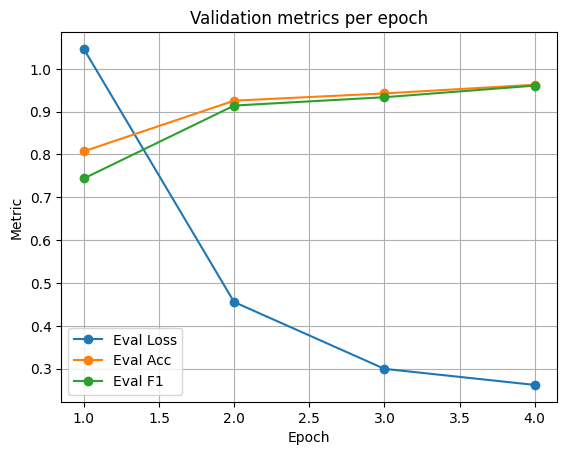

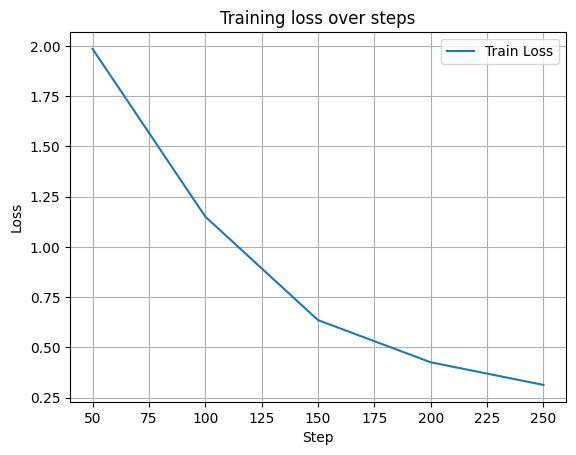

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/log_history.csv")

eval_df = df[df["eval_loss"].notna()]

train_df = df[df["loss"].notna()]


plt.figure()
plt.plot(eval_df["epoch"], eval_df["eval_loss"], marker="o", label="Eval Loss")
plt.plot(eval_df["epoch"], eval_df["eval_accuracy"], marker="o", label="Eval Acc")
plt.plot(eval_df["epoch"], eval_df["eval_f1"], marker="o", label="Eval F1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation metrics per epoch")
plt.legend()
plt.grid(True)
plt.show()

# Train loss
plt.figure()
plt.plot(train_df["step"], train_df["loss"], label="Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training loss over steps")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from optimum.onnxruntime import ORTModelForSequenceClassification

ort_model = ORTModelForSequenceClassification.from_pretrained(
    "saved_model",  # <- tu checkpoint HF
    export=True
)
ort_model.save_pretrained("onnx_model")

tokenizer.save_pretrained("onnx_model")


/usr/local/lib/python3.11/dist-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


('onnx_model/tokenizer_config.json',
 'onnx_model/special_tokens_map.json',
 'onnx_model/vocab.txt',
 'onnx_model/added_tokens.json',
 'onnx_model/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

src_dirs = ["onnx_model", "saved_model", "outputs"]
src_file = "train.jsonl"

dst_base = Path("/content/drive/MyDrive/Portfolio/NLP-Feedback-classifier/models")
dst_base.mkdir(parents=True, exist_ok=True)

for d in src_dirs:
    src = Path(d)
    if src.exists():
        print(f"🔄 Copiando carpeta {d}…")
        shutil.copytree(src, dst_base / src.name, dirs_exist_ok=True)
    else:
        print(f"⚠️  La carpeta {d} no existe, la salto.")

src = Path(src_file)
if src.exists():
    print(f"🔄 Copiando archivo {src_file}…")
    shutil.copy2(src, dst_base / src.name)
else:
    print(f"⚠️  El archivo {src_file} no existe, lo salto.")

print("✅ Copia completada en", dst_base)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Copiando carpeta onnx_model…
🔄 Copiando carpeta saved_model…
🔄 Copiando carpeta outputs…
🔄 Copiando archivo train.jsonl…
✅ Copia completada en /content/drive/MyDrive/Portfolio/NLP-Feedback-classifier/models


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

preds_output = trainer.predict(ds_encoded["test"])
preds = np.argmax(preds_output.predictions, axis=-1)
refs  = preds_output.label_ids

print("Classification report:\n",
      classification_report(refs, preds, target_names=list(id2label.values())))
print("Confusion matrix:\n", confusion_matrix(refs, preds))


Classification report:
                          precision    recall  f1-score   support

           changed_mind       1.00      0.92      0.96        13
        fees_unexpected       1.00      1.00      1.00        28
  income_not_verifiable       1.00      1.00      1.00        27
                  other       0.97      1.00      0.99        34
    process_too_complex       1.00      1.00      1.00        54
        technical_issue       0.79      0.86      0.83        22
               ui_error       1.00      0.59      0.74        17
    unexpected_behavior       0.89      1.00      0.94        42
waiting_period_too_long       1.00      1.00      1.00        38
           wrong_values       1.00      1.00      1.00        21

               accuracy                           0.96       296
              macro avg       0.97      0.94      0.95       296
           weighted avg       0.97      0.96      0.96       296

Confusion matrix:
 [[12  0  0  1  0  0  0  0  0  0]
 [ 0 28  0 

In [ ]:
from pathlib import Path
import onnxruntime as ort
from transformers import AutoTokenizer
import numpy as np
from scipy.special import softmax

MODEL_DIR = "onnx_model"
session = ort.InferenceSession("onnx_model/model.onnx", providers=["CPUExecutionProvider"])
tokenizer = AutoTokenizer.from_pretrained("onnx_model")

def predict(text: str):
    enc = tokenizer(text, return_tensors="np", truncation=True,
                    padding="max_length", max_length=128)
    logits = session.run(None, dict(enc))[0]
    label_id = int(np.argmax(logits, axis=-1))

    scores = softmax(logits, axis=-1)
    score = float(np.max(scores))
    return {"label": id2label[label_id], "score": score}

In [ ]:
# {"reason": "unexpected_behavior", "free_text": "I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.", "step": "Borrower Selection", "id": "ex-00017"}
# {"reason": "technical_issue", "free_text": "I was trying to upload my documents, but the website kept crashing and wouldn\u2019t let me proceed. It was really frustrating, so I had to stop the application.", "step": "Verify Liabilities", "id": "ex-00018"}
# {"reason": "other", "free_text": "I realized I need to discuss some financial details with my advisor before proceeding further with the application.", "step": "Verify Liabilities", "id": "ex-00019"}

for text in [
    "I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.",
    "I was trying to upload my documents, but the website kept crashing and wouldn\u2019t let me proceed. It was really frustrating, so I had to stop the application.",
    "I realized I need to discuss some financial details with my advisor before proceeding further with the application."
]:
    pred = predict(text)
    print(f"INPUT : {text}")
    print(f"PREDICCIÓN → etiqueta: {pred['label']}  puntuación: {pred['score']:.4f}\n")


/tmp/ipython-input-137-3998171667.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_id = int(np.argmax(logits, axis=-1))


INPUT : I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.
PREDICCIÓN → etiqueta: unexpected_behavior  puntuación: 0.8882

INPUT : I was trying to upload my documents, but the website kept crashing and wouldn’t let me proceed. It was really frustrating, so I had to stop the application.
PREDICCIÓN → etiqueta: technical_issue  puntuación: 0.5080

INPUT : I realized I need to discuss some financial details with my advisor before proceeding further with the application.
PREDICCIÓN → etiqueta: other  puntuación: 0.9076



In [ ]:
import numpy as np

def predict_all(text: str):
    pred = predict(text)
    print(f"\n▶️  PREDICCIÓN rápida → etiqueta: {pred['label']}, score: {pred['score']:.4f}\n")


    enc = tokenizer(text, return_tensors="np", truncation=True, padding="max_length", max_length=128)
    logits = session.run(None, dict(enc))[0]            # shape (1, num_labels)
    probs  = np.exp(logits) / np.exp(logits).sum(-1, keepdims=True)

    # 3) Imprime probabilidades en orden de etiquetas
    print("Probabilidades por etiqueta:")
    for label, p in zip(id2label.values(), probs[0]):
        print(f"  {label:25s} → {p:.3f}")


In [ ]:

texts = [
    "I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.",
    "I was trying to upload my documents, but the website kept crashing and wouldn\u2019t let me proceed. It was really frustrating, so I had to stop the application.",
    "I realized I need to discuss some financial details with my advisor before proceeding further with the application."
]

texts = [
    "I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.",
    "I was trying to upload my documents, but the website kept crashing and wouldn\u2019t let me proceed. It was really frustrating, so I had to stop the application.",
    "I realized I need to discuss some financial details with my advisor before proceeding further with the application."
]

for t in texts:
    predict_all(t)


/tmp/ipython-input-114-1737103459.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_id = int(np.argmax(logits, axis=-1))


changed_mind              → 0.433
fees_unexpected           → 0.567
changed_mind              → 0.433
fees_unexpected           → 0.567
changed_mind              → 0.431
fees_unexpected           → 0.569


In [ ]:
print("Clases cargadas:", len(id2label), id2label)


Clases cargadas: 10 {0: 'changed_mind', 1: 'fees_unexpected', 2: 'income_not_verifiable', 3: 'other', 4: 'process_too_complex', 5: 'technical_issue', 6: 'ui_error', 7: 'unexpected_behavior', 8: 'waiting_period_too_long', 9: 'wrong_values'}


In [ ]:
enc = tokenizer("test", return_tensors="np", truncation=True, padding="max_length", max_length=128)
logits = session.run(None, dict(enc))[0]
print("logits shape:", logits.shape)          # debería ser (1, 10)
print("num_labels in config:", model.config.num_labels)


logits shape: (1, 2)
num_labels in config: 10


In [ ]:
import numpy as np

THRESHOLD = 0.65
TOPK = 3

def predict_with_threshold(text):
    enc = tokenizer(text, return_tensors="np", truncation=True, padding="max_length", max_length=128)
    logits = session.run(None, dict(enc))[0]
    probs = np.exp(logits - logits.max()) / np.exp(logits - logits.max()).sum(-1, keepdims=True)
    probs = probs[0]

    top_idx = probs.argmax()
    top_label = id2label[top_idx]
    top_score = probs[top_idx]

    if top_score >= THRESHOLD:
        return {"label": top_label, "score": float(top_score)}
    else:
        order = probs.argsort()[::-1][:TOPK]
        return {
            "label": None,
            "score": float(top_score),
            "candidates": [(id2label[i], float(probs[i])) for i in order]
        }


In [ ]:
texts = [
    "I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.",
    "I was trying to upload my documents, but the website kept crashing and wouldn\u2019t let me proceed. It was really frustrating, so I had to stop the application.",
    "I realized I need to discuss some financial details with my advisor before proceeding further with the application."
]
for t in texts:
    res = predict_with_threshold(t)
    print("INPUT:", t)
    if res["label"] is not None:
        print(f"✔ Predicción segura: {res['label']}  (p={res['score']:.3f})\n")
    else:
        print(f"⚠ Baja confianza (p={res['score']:.3f}). Top-{TOPK} candidatas:")
        for lbl, p in res["candidates"]:
            print(f"   - {lbl:25s} → {p:.3f}")
        print()

INPUT: I was filling out the application, but suddenly the page froze and some fields disappeared. It was confusing and made me lose trust in the system, so I stopped the process.
✔ Predicción segura: unexpected_behavior  (p=0.888)

INPUT: I was trying to upload my documents, but the website kept crashing and wouldn’t let me proceed. It was really frustrating, so I had to stop the application.
⚠ Baja confianza (p=0.508). Top-3 candidatas:
   - technical_issue           → 0.508
   - unexpected_behavior       → 0.211
   - ui_error                  → 0.158

INPUT: I realized I need to discuss some financial details with my advisor before proceeding further with the application.
✔ Predicción segura: other  (p=0.908)



In [ ]:
import json
raw_jsonl = """
{"reason": "waiting_period_too_long", "free_text": "I started the application but the waiting time for verification is too long, so I decided to stop for now.", "step": "Verify Liabilities", "id": "ex-00192"}
{"reason": "unexpected_behavior", "free_text": "I was filling out the application but the form kept refreshing unexpectedly and my inputs got erased multiple times. It was frustrating and I couldn\u2019t continue.", "step": "Borrower Selection", "id": "ex-00193"}
{"reason": "fees_unexpected", "free_text": "I was surprised by the additional fees that appeared towards the end of the application. These unexpected costs make me reconsider proceeding further.", "step": "Prepare Disclosure", "id": "ex-00194"}
{"reason": "income_not_verifiable", "free_text": "I was unable to provide the necessary proof of income documents as requested, so I had to stop the application process.", "step": "Verify Liabilities", "id": "ex-00195"}
{"reason": "other", "free_text": "I had some unexpected personal matters come up and won\u2019t be able to continue with my mortgage application right now. Thank you for your understanding.", "step": "Borrower Selection", "id": "ex-00196"}
{"reason": "process_too_complex", "free_text": "I started the mortgage application but found the process too complicated to complete without more guidance. It was overwhelming to gather all the required documents and understand the next steps.", "step": "Verify Liabilities", "id": "ex-00197"}
{"reason": "waiting_period_too_long", "free_text": "I was really interested in proceeding with the mortgage application, but the waiting times between each step have been longer than I expected. It\u2019s making it difficult to plan ahead, so I\u2019ve decided to pause my application for now.", "step": "Credit Check", "id": "ex-00198"}
{"reason": "other", "free_text": "I had to pause my application because I need to discuss some details with my financial advisor before moving forward.", "step": "Verify Liabilities", "id": "ex-00199"}
{"reason": "income_not_verifiable", "free_text": "I was unable to provide the necessary proof of income documents to continue with the application.", "step": "Verify Liabilities", "id": "ex-00200"}
{"reason": "fees_unexpected", "free_text": "I was going through the application but got surprised by the additional fees mentioned. They were higher than I expected, so I decided to stop the process.", "step": "Finalize Application", "id": "ex-00201"}
{"reason": "fees_unexpected", "free_text": "I was filling out the application, but the fees listed at the end were higher than I expected and beyond my budget. I decided not to proceed with the application.", "step": "Finalize Application", "id": "ex-00202"}
{"reason": "technical_issue", "free_text": "I kept encountering an error message every time I tried to upload my income documents. It prevented me from moving forward in the application.", "step": "Verify Liabilities", "id": "ex-00203"}
{"reason": "process_too_complex", "free_text": "I started filling out the mortgage application but found the process really confusing and overwhelming with too many steps and requirements. I think I need something simpler or more guidance before continuing.", "step": "Verify Liabilities", "id": "ex-00204"}
{"reason": "wrong_values", "free_text": "I noticed that the income figures I entered were not saving correctly and kept resetting to zero. This made me doubt the accuracy of the application, so I decided to stop and review my information before proceeding.", "step": "Verify Liabilities", "id": "ex-00205"}
{"reason": "waiting_period_too_long", "free_text": "I was really interested in proceeding with the mortgage application, but the waiting time for credit approval is longer than I expected. Unfortunately, I need a quicker response and will have to look elsewhere.", "step": "Credit Check", "id": "ex-00206"}
{"reason": "unexpected_behavior", "free_text": "I was filling out the application, but the website kept refreshing randomly and my entered data disappeared. That was really frustrating, so I decided to stop the process.", "step": "Verify Liabilities", "id": "ex-00207"}
{"reason": "other", "free_text": "I had to pause my application because I need to gather some more documents and discuss with my spouse before proceeding.", "step": "Verify Liabilities", "id": "ex-00208"}
""".strip()

# Parsear
records = [json.loads(line) for line in raw_jsonl.splitlines()]

# Lista solo de textos
texts = [r["free_text"] for r in records]

for t in texts:
    res = predict_with_threshold(t)
    print("INPUT:", t)
    if res["label"] is not None:
        print(f"✔ Predicción segura: {res['label']}  (p={res['score']:.3f})\n")
    else:
        print(f"⚠ Baja confianza (p={res['score']:.3f}). Top-{TOPK} candidatas:")
        for lbl, p in res["candidates"]:
            print(f"   - {lbl:25s} → {p:.3f}")
        print()

INPUT: I started the application but the waiting time for verification is too long, so I decided to stop for now.
✔ Predicción segura: waiting_period_too_long  (p=0.931)

INPUT: I was filling out the application but the form kept refreshing unexpectedly and my inputs got erased multiple times. It was frustrating and I couldn’t continue.
✔ Predicción segura: unexpected_behavior  (p=0.892)

INPUT: I was surprised by the additional fees that appeared towards the end of the application. These unexpected costs make me reconsider proceeding further.
✔ Predicción segura: fees_unexpected  (p=0.904)

INPUT: I was unable to provide the necessary proof of income documents as requested, so I had to stop the application process.
✔ Predicción segura: income_not_verifiable  (p=0.857)

INPUT: I had some unexpected personal matters come up and won’t be able to continue with my mortgage application right now. Thank you for your understanding.
✔ Predicción segura: other  (p=0.799)

INPUT: I started the m